# Toturial to explore the PLATO-CS catalogues

This notebook investigates the PLATO-CS source catalogues of the LOPS2 and LOPN1, complete for $G < 19$.

In [57]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches, ticker
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 
from shapely.geometry import Point, Polygon

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
import platosim.mocka     as mk
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important;}</style>"))

In [59]:
# Define paths used throughout
path = Path(os.getenv('PLATO_WORKDIR')) / 'PlatoCS'
idir = path / 'input'
pdir = path / 'plots'

# Use seed for reproducebility
seed = 12345
rng = ut.rng(seed)

# Load catalogues
ds = pd.read_feather(idir / 'starcat_PlatoCS_NCAM_LOPS2.ftr')
dn = pd.read_feather(idir / 'starcat_PlatoCS_NCAM_LOPN1.ftr')

FileNotFoundError: [Errno 2] No such file or directory: '/lhome/nicholas/software/workdir/PlatoCS/input/starcat_PlatoCS_NCAM_LOPS2.ftr'

In [56]:
ds.columns

Index(['gaiaDR3', 'ra', 'dec', 'l', 'b', 'Pmag', 'PBmag', 'PRmag', 'Gmag',
       'BP_RP', 'Ag', 'Mg', 'plx', 'plx_err', 'd', 'd_err', 'pm', 'pmra',
       'pmra_error', 'pmdec', 'pmdec_error', 'ruwe', 'mh', 'mh_low', 'mh_upp',
       'logg', 'logg_low', 'logg_upp', 'Teff', 'Teff_low', 'Teff_upp', 'R',
       'R_low', 'R_upp', 'M', 'M_low', 'M_upp', 'L', 'L_low', 'L_upp', 'spec',
       'evol', 'ncam'],
      dtype='object')

---
## 1. Sky distribution of catalogues
---

<IPython.core.display.Javascript object>


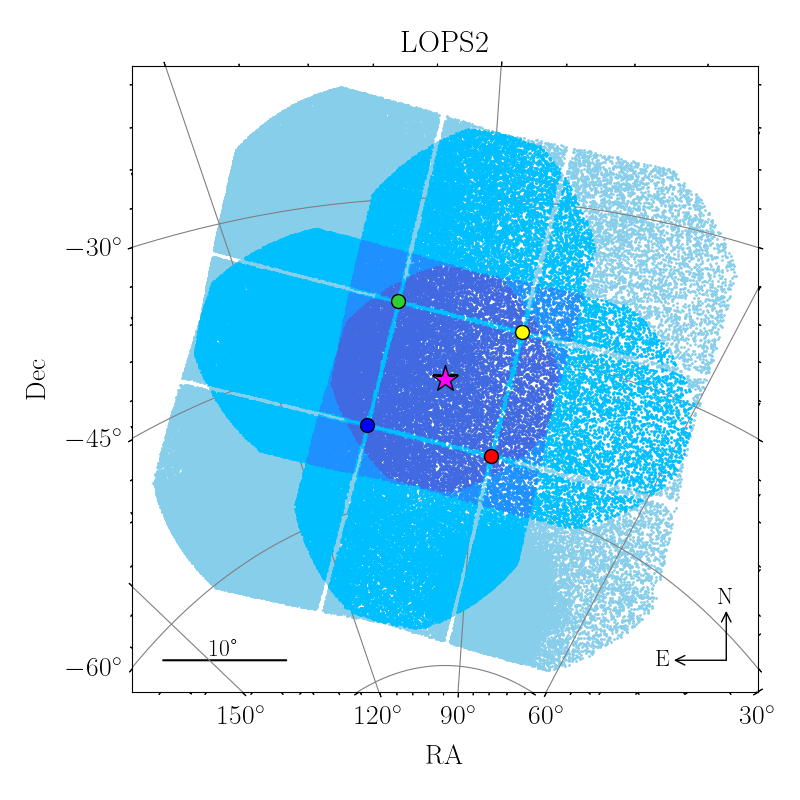

In [4]:
# Show LOPS2 in sky
fig, ax = pt.plotPlatoFOV('LOPS2', showGroups=True, ncamStars=ds.iloc[::100], 
                          title='LOPS2', fovSize=32, fs=20, ms=2, figsize=(8,8))
fig.savefig(pdir / 'starcat_PlatoCS_LOPS2.png', bbox_inches='tight', dpi=300)

<IPython.core.display.Javascript object>


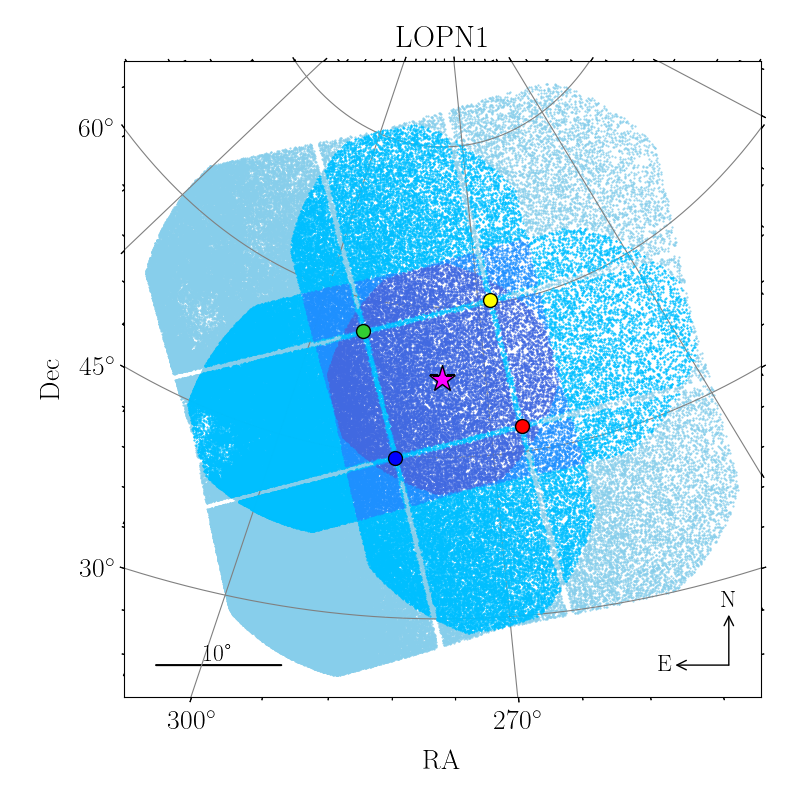

In [5]:
# Show LOPN1 in sky
fig, ax = pt.plotPlatoFOV('LOPN1', showGroups=True, ncamStars=dn.iloc[::100], 
                          title='LOPN1', fovSize=32, fs=20, ms=1, figsize=(8,8))
fig.savefig(pdir / 'starcat_PlatoCS_LOPN1.png', bbox_inches='tight', dpi=300)

---
## 2. Colour absolute Magnitude Diagram (CaMD)
---

In [7]:
# # Fetch the density of each point in CaMD
# dt = df.dropna()
# dx = dt[dt.plx > 1] # < 1000 pc
# x, y, z, dex = ut.sortAfterDensity(dx.BP_RP.to_numpy(), dx.Mg.to_numpy())
# dx = pd.DataFrame({'x':x, 'y':y, 'z':z, 'dex':dex})
# dx.to_feather(path / 'starcat_PlatoCS_LOPS2_GaussianDensity.ftr')

<IPython.core.display.Javascript object>


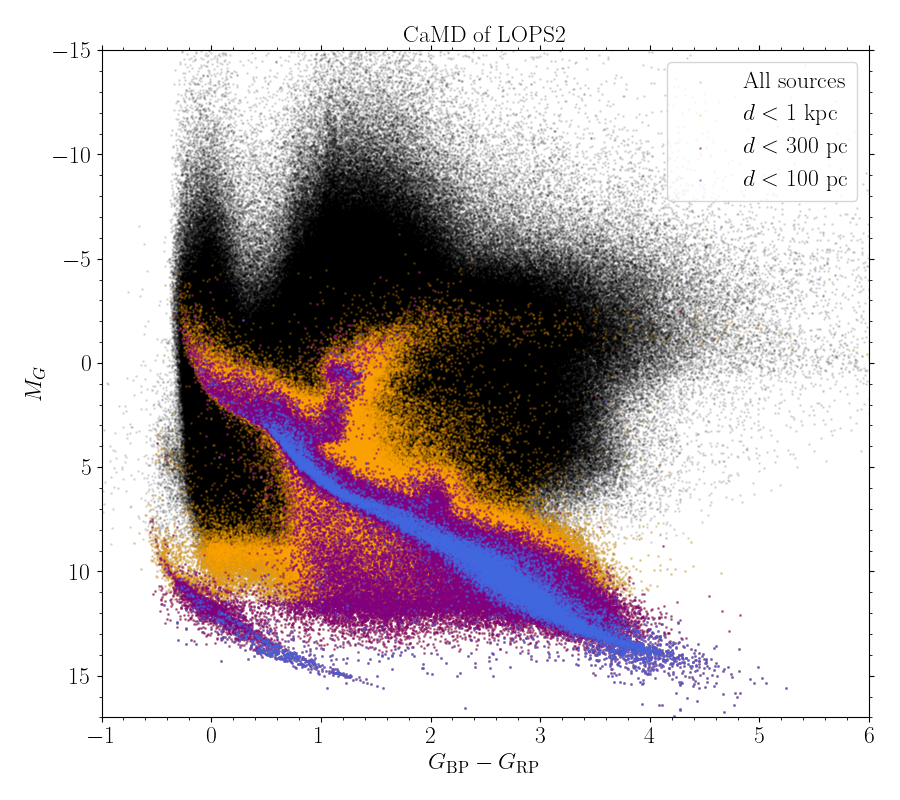

In [20]:
# Cut in distance [pc]
ds0 = ds
ds1 = ds0[ds0.d < 1000]
ds2 = ds0[ds0.d < 300]
ds3 = ds0[ds0.d < 100]

# Plot CaMD of all stars
fig, ax = plt.subplots(1,1, figsize=(9,8))
im = ax.scatter(ds0.BP_RP, ds0.Mg, s=1, color='k',         alpha=0.1, label='All sources')
im = ax.scatter(ds1.BP_RP, ds1.Mg, s=1, color='orange',    alpha=0.2, label=r'$d<$ 1 kpc')
im = ax.scatter(ds2.BP_RP, ds2.Mg, s=1, color='purple',    alpha=0.4, label=r'$d<$ 300 pc')
im = ax.scatter(ds3.BP_RP, ds3.Mg, s=1, color='royalblue', alpha=0.4, label=r'$d<$ 100 pc')
ax.legend(loc='upper right')
ax.set_title('CaMD of LOPS2')
ax.set_xlabel(r'$G_{\rm BP} - G_{\rm RP}$')
ax.set_ylabel(r'$M_G$')
ax.set_xlim(-1, 6)
ax.set_ylim(17, -15)
plt.tight_layout();

<IPython.core.display.Javascript object>


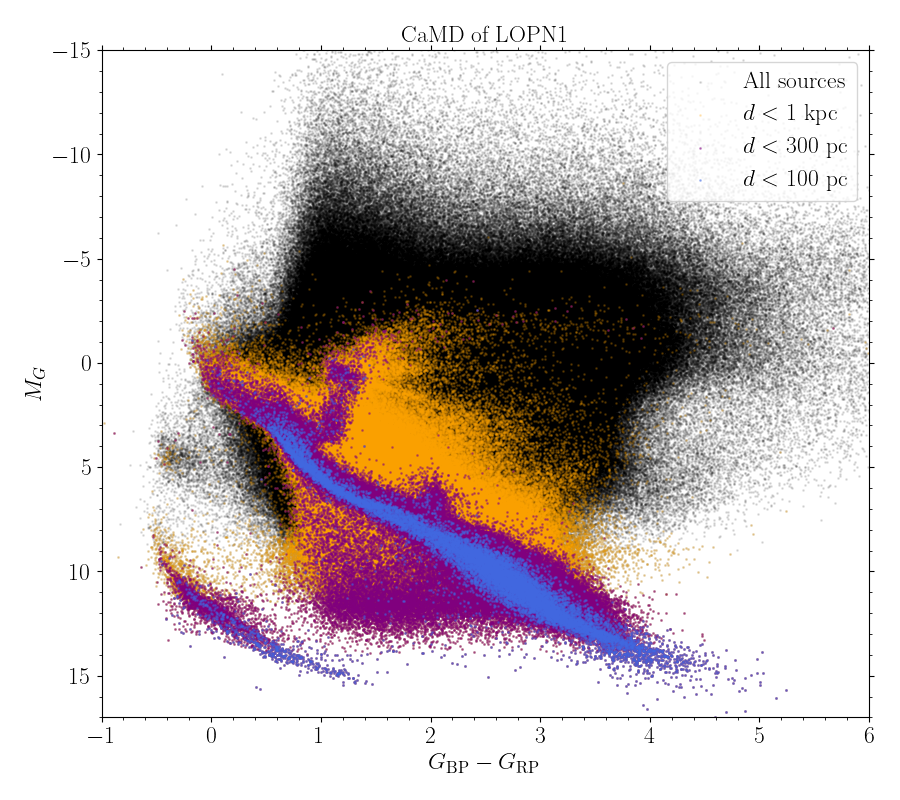

In [22]:
# Cut in distance [pc]
dn0 = dn
dn1 = dn0[dn0.d < 1000]
dn2 = dn0[dn0.d < 300]
dn3 = dn0[dn0.d < 100]

# Plot CaMD of all stars
fig, ax = plt.subplots(1,1, figsize=(9,8))
im = ax.scatter(dn0.BP_RP, dn0.Mg, s=1, color='k',         alpha=0.1, label='All sources')
im = ax.scatter(dn1.BP_RP, dn1.Mg, s=1, color='orange',    alpha=0.2, label=r'$d<$ 1 kpc')
im = ax.scatter(dn2.BP_RP, dn2.Mg, s=1, color='purple',    alpha=0.4, label=r'$d<$ 300 pc')
im = ax.scatter(dn3.BP_RP, dn3.Mg, s=1, color='royalblue', alpha=0.4, label=r'$d<$ 100 pc')
ax.legend(loc='upper right')
ax.set_title('CaMD of LOPN1')
ax.set_xlabel(r'$G_{\rm BP} - G_{\rm RP}$')
ax.set_ylabel(r'$M_G$')
ax.set_xlim(-1, 6)
ax.set_ylim(17, -15)
plt.tight_layout();

---
## 3. Number statistics
---

In [32]:
order = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'unknown', 'CSTAR']

Catalogue statistic for LOPS2
--------------------------------
Number of stars in total       : 28358171
Number of stars w.  extinction : 24952287
Number of stars w/o extinction : 3405884
Number of potential binaries   : 2337925
Number of potential binaries   : 1624718


<IPython.core.display.Javascript object>


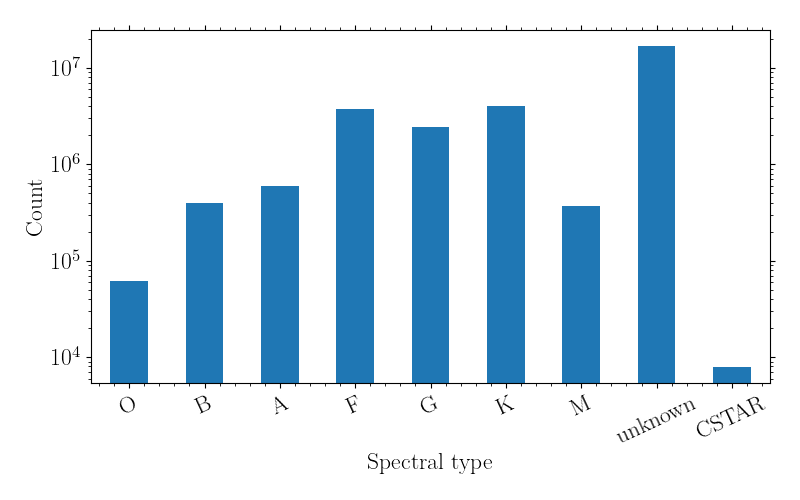

<IPython.core.display.Javascript object>


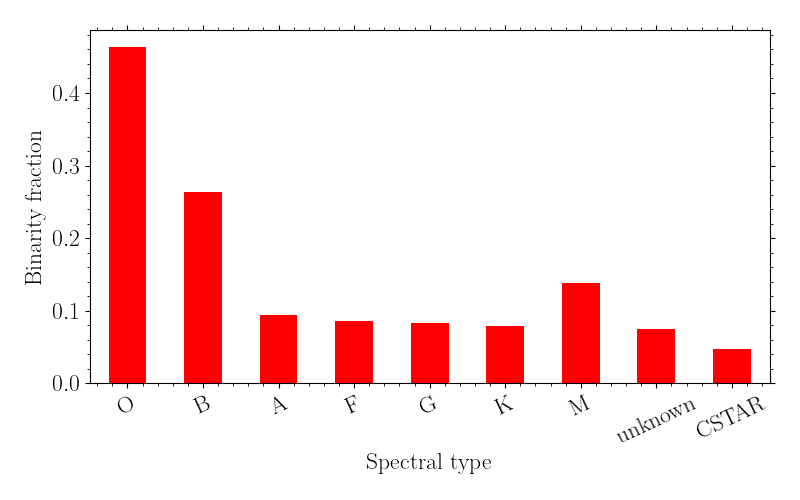

In [39]:
print('Catalogue statistic for LOPS2')
print('--------------------------------')
print('Number of stars in total       :', ds.shape[0])
print('Number of stars w.  extinction :', ds.dropna(subset=["Ag"]).shape[0])
print('Number of stars w/o extinction :', ds[ds.Ag.isna()].shape[0])
print('Number of potential binaries   :', ds[ds.ruwe > 1.2].shape[0])
print('Number of potential binaries   :', ds[ds.ruwe > 1.4].shape[0])

# Histogram of sources in LOPS2
fig, ax = plt.subplots(1,1, figsize=(8,5))
ds.spec.value_counts().loc[order].plot.bar(rot=25)
ax.set_xlabel('Spectral type')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()

# Binarity fraction in LOPS2
fig, ax = plt.subplots(1,1, figsize=(8,5))
ds0 = ds.spec.value_counts().loc[order]
ds1 = ds[ds.ruwe > 1.2].spec.value_counts().loc[order]
(ds1/ds0).plot.bar(rot=25, color='r')
ax.set_xlabel('Spectral type')
ax.set_ylabel('Binarity fraction')
plt.tight_layout();

Catalogue statistic for LOPN1
--------------------------------
Number of stars in total       : 29570706
Number of stars w.  extinction : 26116950
Number of stars w/o extinction : 3453756
Number of potential binaries   : 2301883
Number of potential binaries   : 1615305


<IPython.core.display.Javascript object>


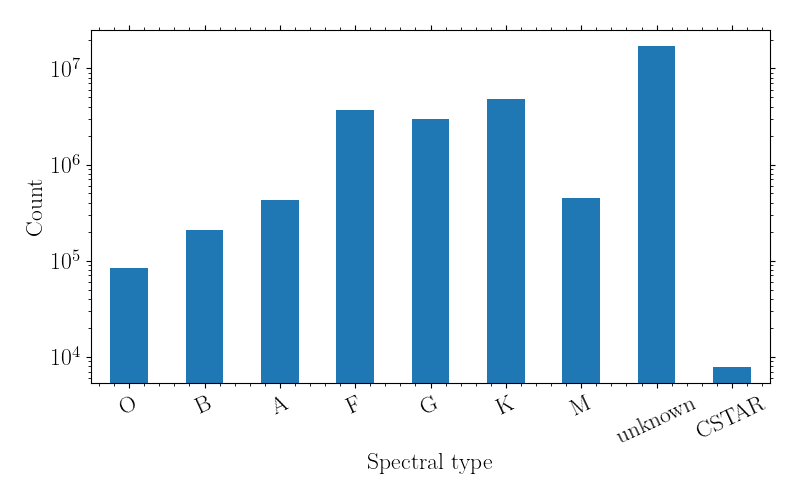

<IPython.core.display.Javascript object>


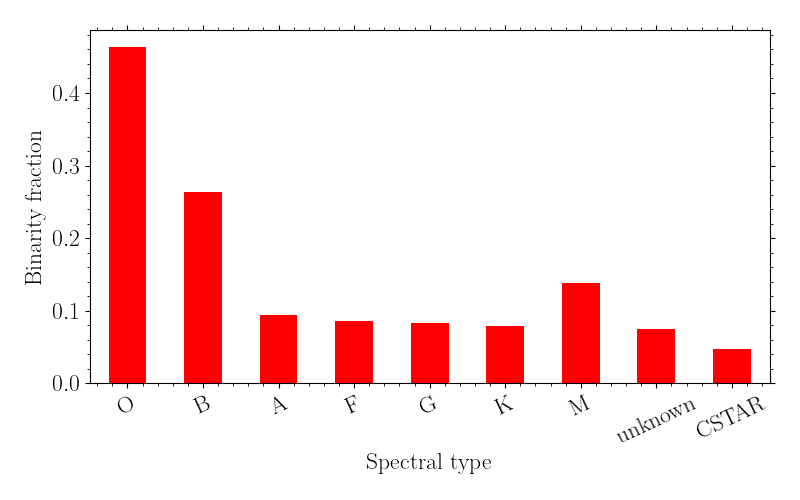

In [40]:
print('Catalogue statistic for LOPN1')
print('--------------------------------')
print('Number of stars in total       :', dn.shape[0])
print('Number of stars w.  extinction :', dn.dropna(subset=["Ag"]).shape[0])
print('Number of stars w/o extinction :', dn[dn.Ag.isna()].shape[0])
print('Number of potential binaries   :', dn[dn.ruwe > 1.2].shape[0])
print('Number of potential binaries   :', dn[dn.ruwe > 1.4].shape[0])

# Histogram of sources in LOPN1
fig, ax = plt.subplots(1,1, figsize=(8,5))
dn.spec.value_counts().loc[order].plot.bar(rot=25)
ax.set_xlabel('Spectral type')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()

# Binarity fraction in LOPN1
fig, ax = plt.subplots(1,1, figsize=(8,5))
dn0 = dn.spec.value_counts().loc[order]
dn1 = dn[dn.ruwe > 1.2].spec.value_counts().loc[order]
(ds1/ds0).plot.bar(rot=25, color='r')
ax.set_xlabel('Spectral type')
ax.set_ylabel('Binarity fraction')
plt.tight_layout();

---
## 4. Parameter distributions
---

<IPython.core.display.Javascript object>


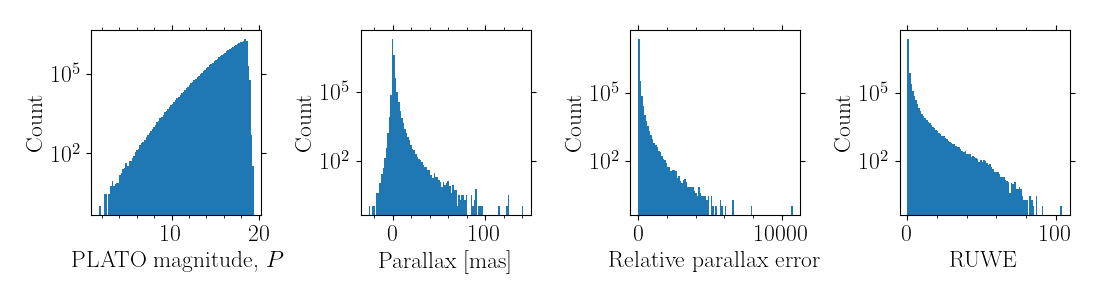

In [49]:
# Plot a few parameters from LOPS2 sources
dx = ds[(ds.Pmag > 0) & (ds.plx < 200) & (ds.plx_err/ds.plx < 1)]
fig, ax = plt.subplots(1, 4, figsize=(11,3))
bins = 100

# Inspect P magnitudes
ax[0].hist(dx.Pmag, bins=bins)
ax[0].set_xlabel(r'PLATO magnitude, $P$')
ax[0].set_ylabel('Count')
ax[0].set_yscale('log')

# Inspect parallax
ax[1].hist(dx.plx, bins=bins)
ax[1].set_xlabel(r'Parallax [mas]')
ax[1].set_ylabel('Count')
ax[1].set_yscale('log')

# Inspect parallax uncertainties
ax[2].hist(np.abs(dx.plx/dx.plx_err), bins=bins)
ax[2].set_xlabel('Relative parallax error')
ax[2].set_ylabel('Count')
ax[2].set_yscale('log')

# Inspect RUWE for binaries
ax[3].hist(dx.ruwe, bins=bins)
ax[3].set_xlabel('RUWE')
ax[3].set_ylabel('Count')
ax[3].set_yscale('log')

plt.tight_layout();

<IPython.core.display.Javascript object>


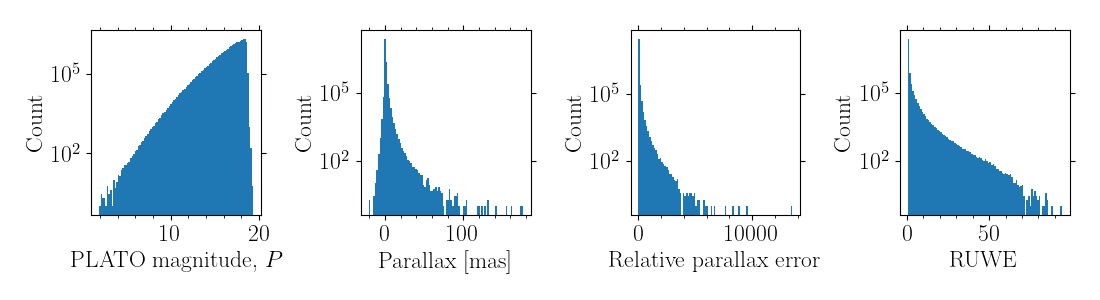

In [50]:
# Plot a few parameters from LOPN1 sources
dx = dn[(dn.Pmag > 0) & (dn.plx < 200) & (dn.plx_err/dn.plx < 1)]
fig, ax = plt.subplots(1, 4, figsize=(11,3))
bins = 100

# Inspect P magnitudes
ax[0].hist(dx.Pmag, bins=bins)
ax[0].set_xlabel(r'PLATO magnitude, $P$')
ax[0].set_ylabel('Count')
ax[0].set_yscale('log')

# Inspect parallax
ax[1].hist(dx.plx, bins=bins)
ax[1].set_xlabel(r'Parallax [mas]')
ax[1].set_ylabel('Count')
ax[1].set_yscale('log')

# Inspect parallax uncertainties
ax[2].hist(np.abs(dx.plx/dx.plx_err), bins=bins)
ax[2].set_xlabel('Relative parallax error')
ax[2].set_ylabel('Count')
ax[2].set_yscale('log')

# Inspect RUWE for binaries
ax[3].hist(dx.ruwe, bins=bins)
ax[3].set_xlabel('RUWE')
ax[3].set_ylabel('Count')
ax[3].set_yscale('log')

plt.tight_layout();